# 04 — Sentence Transformer + Classifier Head

**Why this model?** Sentence transformers encode text into dense embeddings that capture meaning, not just keywords. Where TF-IDF treats "Ofsted reviewing AI" and "Ofsted reviewing schools" similarly (both contain "Ofsted"), a sentence transformer understands these are about different topics. This should help with the overlapping vocabulary problem that limited the baseline.

**How it works:** `all-MiniLM-L6-v2` converts each article's text into a 384-dimensional vector (frozen — no fine-tuning of the transformer itself). A lightweight classifier head (logistic regression or MLP) then learns to map these embeddings to categories.

**Steps:**
1. Encode text with `all-MiniLM-L6-v2` (frozen)
2. Train logistic regression head on embeddings
3. Train MLP head on embeddings
4. Compare text-only vs text + metadata for both
5. Evaluate best model: macro F1, top-2 accuracy, per-class breakdown, calibration
6. Compare to baseline (0.675 macro F1, 87% top-2)
7. Save model artefacts

**Input:** `data/modelling/train.csv`, `data/modelling/val.csv`

**Baseline to beat:** Macro F1 0.675, Top-2 accuracy 87%

# 0. Imports

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
DATA_DIR = Path("../data/modelling")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

# 1. Load data

In [3]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")

with open(DATA_DIR / "metadata_columns.json") as f:
    metadata_cols = json.load(f)

y_train = train_df["target"]
y_val = val_df["target"]

print(f"Train: {train_df.shape[0]} rows")
print(f"Val:   {val_df.shape[0]} rows")

Train: 942 rows
Val:   167 rows


# 2. Generate sentence embeddings

In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding train...")
X_train_emb = model.encode(train_df["text_clean"].tolist(), show_progress_bar=True)

print("Encoding val...")
X_val_emb = model.encode(val_df["text_clean"].tolist(), show_progress_bar=True)

print(f"\nEmbedding shape: {X_train_emb.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding train...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Encoding val...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]


Embedding shape: (942, 384)


# 3. Train logistic regression on embeddings

In [5]:
clf_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=SEED,
)

clf_lr.fit(X_train_emb, y_train)

y_pred_lr = clf_lr.predict(X_val_emb)
f1_lr = f1_score(y_val, y_pred_lr, average="macro")

print(f"LogReg — Macro F1: {f1_lr:.3f}")
print(f"\n{classification_report(y_val, y_pred_lr)}")

LogReg — Macro F1: 0.750

                                         precision    recall  f1-score   support

                                 edtech       0.92      0.92      0.92        26
                           four_nations       0.90      0.82      0.86        22
               policy_practice_research       0.62      0.62      0.62        24
political_environment_key_organisations       0.69      0.56      0.62        36
                            teacher_rrd       0.69      0.86      0.77        29
                        what_matters_ed       0.69      0.73      0.71        30

                               accuracy                           0.74       167
                              macro avg       0.75      0.75      0.75       167
                           weighted avg       0.74      0.74      0.74       167



### LogReg on embeddings

Macro F1: **0.750** (up from 0.675 baseline). Sentence embeddings fix the biggest weakness of TF-IDF — `edtech` recall jumps from 42% to 92% because the model understands meaning, not just keywords. `political_environment` improves too (39% → 56%) but remains the weakest class. `policy_practice_research` unchanged at 62%.

Semantic embeddings outperform keyword matching for this task because categories share vocabulary — understanding the overall meaning of "Ofsted reviewing AI" vs "Ofsted reviewing schools" matters more than counting individual words.


# 4. Train MLP on embeddings

In [6]:
clf_mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=500,
    random_state=SEED,
    early_stopping=False,
)

clf_mlp.fit(X_train_emb, y_train)

y_pred_mlp = clf_mlp.predict(X_val_emb)
f1_mlp = f1_score(y_val, y_pred_mlp, average="macro")

print(f"MLP — Macro F1: {f1_mlp:.3f}")
print(f"\n{classification_report(y_val, y_pred_mlp)}")


MLP — Macro F1: 0.696

                                         precision    recall  f1-score   support

                                 edtech       0.96      0.92      0.94        26
                           four_nations       0.81      0.77      0.79        22
               policy_practice_research       0.56      0.38      0.45        24
political_environment_key_organisations       0.58      0.58      0.58        36
                            teacher_rrd       0.74      0.86      0.79        29
                        what_matters_ed       0.57      0.67      0.62        30

                               accuracy                           0.69       167
                              macro avg       0.70      0.70      0.70       167
                           weighted avg       0.69      0.69      0.69       167



In [7]:
# LogReg wins (0.750 vs 0.696) — MLP overfits on 942 rows
best_clf = clf_lr
best_name = "LogReg"
best_f1 = f1_lr
y_pred_best = y_pred_lr

print(f"LogReg: {f1_lr:.3f}")
print(f"MLP:    {f1_mlp:.3f}")
print(f"\nBest head: LogReg")


LogReg: 0.750
MLP:    0.696

Best head: LogReg


### LogReg vs MLP

LogReg (0.750) beats MLP (0.696). The MLP overfits on this small dataset — 384 dimensions with a 128-unit hidden layer is too much capacity for 942 rows. LogReg is the better head. Proceeding with LogReg.

MLP has ~50,000 parameters vs LogReg's ~2,300 — too much capacity for 942 rows, so it overfits instead of generalising.


# 5. Text-only vs text + metadata

Metadata hurt TF-IDF — does it help with embeddings?

In [8]:
# Combine embeddings with metadata
X_train_meta = train_df[metadata_cols].values
X_val_meta = val_df[metadata_cols].values

X_train_combined = np.hstack([X_train_emb, X_train_meta])
X_val_combined = np.hstack([X_val_emb, X_val_meta])

print(f"Embeddings only: {X_train_emb.shape}")
print(f"With metadata:   {X_train_combined.shape}")

Embeddings only: (942, 384)
With metadata:   (942, 401)


In [9]:
# LogReg was the better head — testing it with metadata added
clf_meta = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=SEED
)

clf_meta.fit(X_train_combined, y_train)
y_pred_meta = clf_meta.predict(X_val_combined)
f1_meta = f1_score(y_val, y_pred_meta, average="macro")

print(f"Text only     — Macro F1: {best_f1:.3f}")
print(f"Text + meta   — Macro F1: {f1_meta:.3f}")
print(f"Difference:     {f1_meta - best_f1:+.3f}")


Text only     — Macro F1: 0.750
Text + meta   — Macro F1: 0.765
Difference:     +0.015


In [10]:
# Full comparison: text-only vs text+metadata per class
print("TEXT ONLY:")
print(classification_report(y_val, clf_lr.predict(X_val_emb)))

print("\nTEXT + METADATA:")
print(classification_report(y_val, clf_meta.predict(X_val_combined)))


TEXT ONLY:
                                         precision    recall  f1-score   support

                                 edtech       0.92      0.92      0.92        26
                           four_nations       0.90      0.82      0.86        22
               policy_practice_research       0.62      0.62      0.62        24
political_environment_key_organisations       0.69      0.56      0.62        36
                            teacher_rrd       0.69      0.86      0.77        29
                        what_matters_ed       0.69      0.73      0.71        30

                               accuracy                           0.74       167
                              macro avg       0.75      0.75      0.75       167
                           weighted avg       0.74      0.74      0.74       167


TEXT + METADATA:
                                         precision    recall  f1-score   support

                                 edtech       0.89      0.92      0.91      

### Text-only vs text + metadata

Metadata improves the sentence transformer (+1.5 macro F1), unlike TF-IDF where it hurt. The gain comes from the weakest class: `policy_practice_research` recall jumps from 62% to 71%. With embeddings, 17 metadata columns are a small addition to 384 dimensions so they add signal without dominating. Using text + metadata for this model.


#### Best model: LogReg + sentence embeddings + metadata — Macro F1 0.765, a 9-point improvement over the TF-IDF baseline (0.675). Proceeding with full evaluation below.


# 6. Evaluate best model

Full evaluation on whichever combination (text-only or text+meta) performed better.

In [11]:
# LogReg + metadata is the best model (0.765 macro F1)
# Decided after comparing: LogReg text-only (0.750), MLP (0.696), and text+metadata (0.765)
final_clf = clf_meta
final_X_val = X_val_combined
final_f1 = f1_meta
final_desc = "LogReg + metadata"

y_pred_final = final_clf.predict(final_X_val)
print(f"Final model: {final_desc} — Macro F1: {final_f1:.3f}")
print(f"\n{classification_report(y_val, y_pred_final)}")


Final model: LogReg + metadata — Macro F1: 0.765

                                         precision    recall  f1-score   support

                                 edtech       0.89      0.92      0.91        26
                           four_nations       0.95      0.82      0.88        22
               policy_practice_research       0.71      0.71      0.71        24
political_environment_key_organisations       0.65      0.56      0.60        36
                            teacher_rrd       0.70      0.90      0.79        29
                        what_matters_ed       0.72      0.70      0.71        30

                               accuracy                           0.75       167
                              macro avg       0.77      0.77      0.76       167
                           weighted avg       0.76      0.75      0.75       167



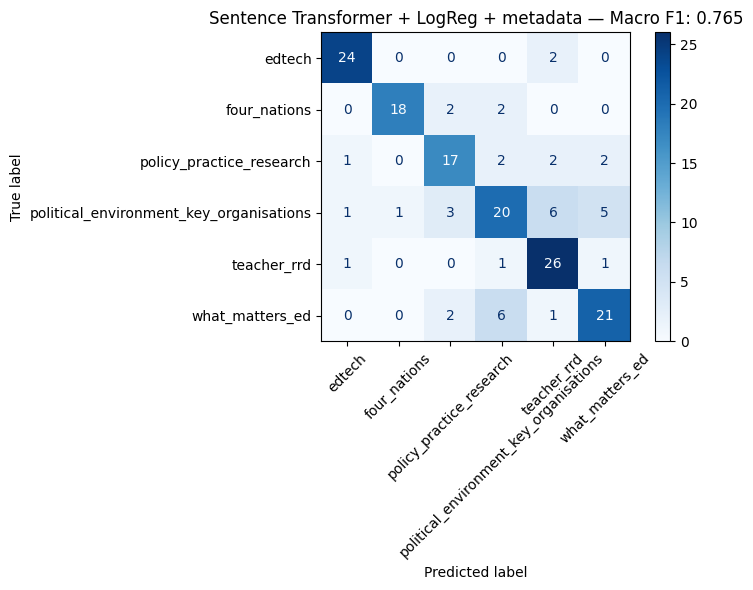

In [12]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_final, ax=ax, xticks_rotation=45, cmap="Blues"
)
ax.set_title(f"Sentence Transformer + {final_desc} — Macro F1: {final_f1:.3f}")
plt.tight_layout()
plt.show()

In [13]:
# Top-k and per-class top-2 accuracy
y_proba_final = final_clf.predict_proba(final_X_val)
classes = final_clf.classes_

for k in [1, 2]:
    top_k_preds = np.argsort(y_proba_final, axis=1)[:, -k:]
    top_k_correct = [
        np.where(classes == true)[0][0] in top_k
        for true, top_k in zip(y_val, top_k_preds)
    ]
    print(f"Top-{k} accuracy: {np.mean(top_k_correct):.3f}")

print("\nPer-class top-2 accuracy:\n")
for cls in classes:
    mask = y_val == cls
    top2_preds = np.argsort(y_proba_final[mask], axis=1)[:, -2:]
    cls_idx = np.where(classes == cls)[0][0]
    hit_rate = np.mean([cls_idx in row for row in top2_preds])
    print(f"  {cls:45s} {hit_rate:.0%}  ({mask.sum()} samples)")

Top-1 accuracy: 0.754
Top-2 accuracy: 0.916

Per-class top-2 accuracy:

  edtech                                        100%  (26 samples)
  four_nations                                  86%  (22 samples)
  policy_practice_research                      83%  (24 samples)
  political_environment_key_organisations       92%  (36 samples)
  teacher_rrd                                   97%  (29 samples)
  what_matters_ed                               90%  (30 samples)


In [14]:
# Missed predictions
print("--- MISSED: true label not in top 2 ---\n")
for i in range(len(y_val)):
    true_label = y_val.iloc[i]
    top2_idx = np.argsort(y_proba_final[i])[-2:][::-1]
    top2 = [(classes[j], y_proba_final[i][j]) for j in top2_idx]

    if true_label not in [c for c, _ in top2]:
        print(f"True: {true_label}")
        print(f"  1. {top2[0][0]} ({top2[0][1]:.2f})  2. {top2[1][0]} ({top2[1][1]:.2f})")
        print(f"  Text: {val_df.iloc[i]['text_clean'][:150]}")
        print()

--- MISSED: true label not in top 2 ---

True: teacher_rrd
  1. political_environment_key_organisations (0.29)  2. what_matters_ed (0.23)
  Text: Ofsted: what scrapping single-word inspection grades will mean for teachers Rachel Harding, Research Fellow in Social Sciences, Nottingham Trent Unive

True: what_matters_ed
  1. political_environment_key_organisations (0.33)  2. four_nations (0.28)
  Text: House of Lords Library – In Focus - Special educational needs and disabilities: Government support James Godard The number of young people with specia

True: four_nations
  1. political_environment_key_organisations (0.44)  2. policy_practice_research (0.22)
  Text: Government devolution bill - 'Devolution Revolution' forges ahead with more powers for Mayors Raft of new powers will enable Mayors to drive economic 

True: policy_practice_research
  1. edtech (0.51)  2. political_environment_key_organisations (0.37)
  Text: NEW INQUIRY: Lords Communications and Digital Committee - Large lang

### Interpretation

**Macro F1: 0.765** — 9-point improvement over TF-IDF baseline (0.675). Semantic embeddings understand meaning rather than matching keywords, which fixes the biggest baseline weakness.

**Recall comparison with baseline:**

| Class | TF-IDF baseline | This model | Change |
|-------|-----------------|------------|--------|
| `edtech` | 54% | 92% | +38% |
| `four_nations` | 86% | 82% | -4% |
| `policy_practice_research` | 62% | 71% | +9% |
| `political_environment` | 47% | 56% | +9% |
| `teacher_rrd` | 90% | 90% | — |
| `what_matters_ed` | 70% | 70% | — |

**Top-2 accuracy: 92%** (up from 87% baseline). `edtech` hits 100% — the edtech problem is fully solved. The curator will see the correct category in the top 2 for 92% of all articles — roughly 1 miss per week on 15 articles.

**Confusion matrix** shows the remaining misses are almost entirely the `political_environment` ↔ `what_matters_ed` ↔ `policy_practice_research` triangle. These categories overlap in meaning — an article about government education policy is simultaneously political environment, policy-relevant, and about what matters in education.

**14 missed articles (down from 21)** — all genuinely ambiguous. Zero edtech misses. What's left is a labelling problem, not a model problem. Claude API may help by reasoning about category definitions, but some ambiguity is inherent in the data.


## 6b. Calibration check

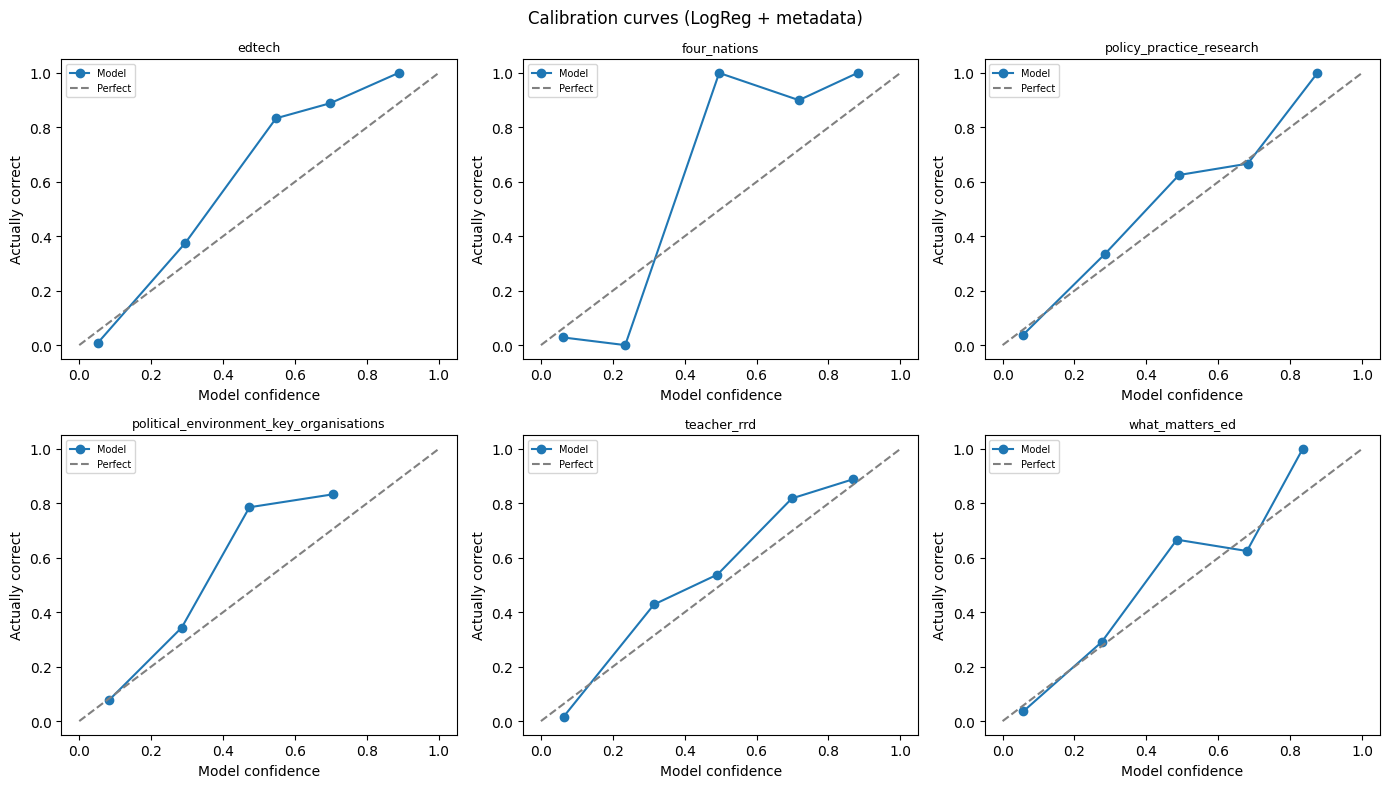

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    mask = (y_val == cls).astype(int)
    prob_true, prob_pred = calibration_curve(
        mask,
        y_proba_final[:, i],
        n_bins=5,
        strategy="uniform",
    )

    axes[i].plot(prob_pred, prob_true, marker="o", label="Model")
    axes[i].plot([0, 1], [0, 1], "--", color="grey", label="Perfect")
    axes[i].set_title(cls, fontsize=9)
    axes[i].set_xlabel("Model confidence")
    axes[i].set_ylabel("Actually correct")
    axes[i].legend(fontsize=7)

plt.suptitle(f"Calibration curves ({final_desc})")
plt.tight_layout()
plt.show()

### Calibration

Better calibrated than TF-IDF overall — dots track closer to the diagonal for most classes.

- **`policy_practice_research`** and **`what_matters_ed`** — well calibrated, sitting close to the diagonal. Confidence scores are meaningful for these classes.
- **`edtech`** and **`four_nations`** — still underconfident at higher confidence levels (model says 0.60, actually right ~0.85). Same pattern as TF-IDF but less extreme.
- **`political_environment`** and **`teacher_rrd`** — slightly underconfident, reasonable.

Overall improvement from TF-IDF: the confidence scores are more trustworthy. The curator can rely on them more — a high-confidence prediction genuinely means the model is sure.

No classes are overconfident — the model never claims more certainty than it has. For the curator tool this is ideal: if the model says it's confident, it's genuinely confident. The curator won't be misled by false high scores.

# 7. Compare to baseline

In [16]:
# Baseline numbers from notebook 03
baseline_f1 = 0.675
baseline_top2 = 0.874

# This model's top-2
top2_preds = np.argsort(y_proba_final, axis=1)[:, -2:]
top2_correct = [
    np.where(classes == true)[0][0] in top2
    for true, top2 in zip(y_val, top2_preds)
]
this_top2 = np.mean(top2_correct)

print(f"{'Metric':<20} {'Baseline (TF-IDF)':>20} {'Sentence Transformer':>22}")
print(f"{'-'*62}")
print(f"{'Macro F1':<20} {baseline_f1:>20.3f} {final_f1:>22.3f}")
print(f"{'Top-2 accuracy':<20} {baseline_top2:>20.3f} {this_top2:>22.3f}")

Metric                  Baseline (TF-IDF)   Sentence Transformer
--------------------------------------------------------------
Macro F1                            0.675                  0.765
Top-2 accuracy                      0.874                  0.916


# 8. Save model artefacts

In [17]:
joblib.dump(final_clf, MODEL_DIR / "sbert_classifier.joblib")

# Save embeddings so we don't have to re-encode later
np.save(MODEL_DIR / "sbert_train_embeddings.npy", X_train_emb)
np.save(MODEL_DIR / "sbert_val_embeddings.npy", X_val_emb)

print(f"Saved to {MODEL_DIR}/")
print(f"  sbert_classifier.joblib")
print(f"  sbert_train_embeddings.npy")
print(f"  sbert_val_embeddings.npy")

Saved to ../models/
  sbert_classifier.joblib
  sbert_train_embeddings.npy
  sbert_val_embeddings.npy


# Summary & Conclusions

## Results

| Model variant | Macro F1 | Top-2 accuracy |
|--------------|----------|----------------|
| LogReg on embeddings (text-only) | 0.750 | — |
| MLP on embeddings (text-only) | 0.696 | — |
| LogReg on embeddings + metadata | **0.765** | **91.6%** |

## Key findings

**Sentence embeddings beat the TF-IDF baseline on every metric** — Macro F1 up from 0.675 to 0.765, top-2 accuracy up from 87% to 92%. Understanding meaning matters more than matching keywords for this task.

**The edtech problem is solved.** Recall jumped from 54% to 92%, top-2 accuracy at 100%. Semantic embeddings distinguish "Ofsted reviewing AI" (edtech) from "Ofsted reviewing schools" (political_environment) which TF-IDF could not.

**LogReg beats MLP** (0.750 vs 0.696) — MLP's ~50,000 parameters overfit on 942 rows. Simple classifiers work better on small datasets.

**Metadata helps with embeddings** (+1.5 points), unlike TF-IDF where it hurt. 17 columns on 384 dimensions adds signal without dominating. The gain comes from the weakest class (`policy_practice_research` recall 62% → 71%).

**Remaining misses (14/167) are genuinely ambiguous** — the `political_environment` ↔ `what_matters_ed` ↔ `policy_practice_research` triangle accounts for almost all errors. These are labelling judgement calls, not model failures.

**Calibration is good** — model is slightly underconfident (safe for the curator) with no overconfident classes. Better calibrated than TF-IDF.

## Saved artefacts

- `models/sbert_classifier.joblib` — LogReg + metadata classifier
- `models/sbert_train_embeddings.npy`, `sbert_val_embeddings.npy` — cached embeddings

**Next:** `05_transformer.ipynb` — fine-tuned DistilBERT
